In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

# Define the project's data and output directories.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"

CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Load the original datasets.
customers = pd.read_csv(DATA_DIR / "customers.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
products = pd.read_csv(DATA_DIR / "products.csv")

# Inspect each dataset.
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments,
    "Products": products
}

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print(df.head())
    print(df.info())


--- Customers ---
Shape: (10000, 5)
Columns: ['CustomerID', 'Age', 'City', 'SignupDate', 'CustomerSegment']
   CustomerID   Age    City  SignupDate CustomerSegment
0      100001  22.0  Tehran  2023-09-11         Regular
1      100002  55.0  Tabriz  2024-01-16             VIP
2      100003  49.0   Karaj  2025-07-31             New
3      100004  39.0  Tehran  2023-04-23             New
4      100005  38.0  Tehran  2023-04-29         Regular
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       10000 non-null  int64  
 1   Age              9820 non-null   float64
 2   City             9881 non-null   object 
 3   SignupDate       10000 non-null  object 
 4   CustomerSegment  10000 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 390.8+ KB
None

--- Orders ---
Shape: (50120, 8)
Columns: ['OrderID', 'C

In [3]:
# Summarize data quality for each original dataset.
quality_results = []

for name, df in datasets.items():
    quality_results.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing_Cells": int(df.isna().sum().sum()),
        "Duplicate_Rows": int(df.duplicated().sum())
    })

quality_report = pd.DataFrame(quality_results)

print(quality_report)

quality_report.to_csv(
    TABLE_DIR / "data_quality_summary.csv",
    index=False
)

     Dataset   Rows  Columns  Missing_Cells  Duplicate_Rows
0  Customers  10000        5            299               0
1     Orders  50120        8            788             120
2   Payments  50000        4             35               0
3   Products     20        4              0               0


In [4]:
# Calculate missing-value counts and percentages.
for name, df in datasets.items():
    missing_report = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage": (
            df.isna().mean() * 100
        ).round(2)
    })

    print(f"\n{name} - Missing Values")
    print(missing_report[missing_report["Missing_Count"] > 0])


Customers - Missing Values
      Missing_Count  Missing_Percentage
Age             180                1.80
City            119                1.19

Orders - Missing Values
               Missing_Count  Missing_Percentage
OrderDate                 35                0.07
Quantity                  80                0.16
Discount                 221                0.44
PaymentMethod            452                0.90

Payments - Missing Values
             Missing_Count  Missing_Percentage
PaymentDate             35                0.07

Products - Missing Values
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


In [5]:
# Identify columns that may require type conversion.
for name, df in datasets.items():
    print(f"\n{name} - Data Types")
    print(df.dtypes)


Customers - Data Types
CustomerID           int64
Age                float64
City                object
SignupDate          object
CustomerSegment     object
dtype: object

Orders - Data Types
OrderID            int64
CustomerID         int64
OrderDate         object
ProductID          int64
Quantity         float64
Discount         float64
PaymentMethod     object
Status            object
dtype: object

Payments - Data Types
PaymentID         int64
OrderID           int64
PaymentDate      object
PaymentStatus    object
dtype: object

Products - Data Types
ProductID        int64
ProductName     object
Category        object
UnitPrice      float64
dtype: object


In [6]:
# Identify duplicate order records without deleting them yet.
duplicate_orders = orders[
    orders.duplicated(keep=False)
].sort_values("OrderID")

print("Rows involved in duplicate records:", len(duplicate_orders))
print(duplicate_orders.head(20))

Rows involved in duplicate records: 240
       OrderID  CustomerID   OrderDate  ProductID  Quantity  Discount  \
199     500200      104768  2025-08-03       2008       2.0      0.10   
50002   500200      104768  2025-08-03       2008       2.0      0.10   
725     500726      102977  2025-11-26       2013       2.0      0.10   
50061   500726      102977  2025-11-26       2013       2.0      0.10   
50022   500822      100897  2026-01-03       2003       1.0      0.00   
821     500822      100897  2026-01-03       2003       1.0      0.00   
1414    501415      108793  2025-02-28       2004       1.0      0.10   
50013   501415      108793  2025-02-28       2004       1.0      0.10   
50092   501813      108688  2025-12-20       2014       2.0      0.10   
1812    501813      108688  2025-12-20       2014       2.0      0.10   
2530    502531      103785  2025-07-07       2002       3.0      0.00   
50077   502531      103785  2025-07-07       2002       3.0      0.00   
50052   503

In [7]:
# Remove only completely identical order records.
orders = orders.drop_duplicates().copy()

print("Orders after exact deduplication:", orders.shape)
print("Unique order IDs:", orders["OrderID"].nunique())

Orders after exact deduplication: (50000, 8)
Unique order IDs: 50000


In [8]:
# Convert date columns to datetime.
orders["OrderDate"] = pd.to_datetime(
    orders["OrderDate"], errors="coerce"
)

customers["SignupDate"] = pd.to_datetime(
    customers["SignupDate"], errors="coerce"
)

payments["PaymentDate"] = pd.to_datetime(
    payments["PaymentDate"], errors="coerce"
)

# Convert numeric fields safely.
for col in ["Quantity", "Discount"]:
    orders[col] = pd.to_numeric(
        orders[col], errors="coerce"
    )

customers["Age"] = pd.to_numeric(
    customers["Age"], errors="coerce"
)

products["UnitPrice"] = pd.to_numeric(
    products["UnitPrice"], errors="coerce"
)

# Display the remaining missing values.
print(orders.isna().sum())
print(customers.isna().sum())
print(products.isna().sum())

OrderID            0
CustomerID         0
OrderDate         35
ProductID          0
Quantity          80
Discount         220
PaymentMethod    450
Status             0
dtype: int64
CustomerID           0
Age                180
City               119
SignupDate           0
CustomerSegment      0
dtype: int64
ProductID      0
ProductName    0
Category       0
UnitPrice      0
dtype: int64


In [9]:
# Convert fractional discounts to percentage values when appropriate.
discount_max = orders["Discount"].max()

if pd.notna(discount_max) and discount_max <= 1:
    orders["Discount"] = orders["Discount"] * 100

print("Standardized discount values:")
print(sorted(orders["Discount"].dropna().unique()))

Standardized discount values:
[np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(30.0)]


In [10]:
# Normalize whitespace and capitalization.
customers["City"] = customers["City"].astype("string").str.strip()

# Correct known variations after inspecting the dataset.
city_corrections = {
    "tehran": "Tehran",
    "Mashad": "Mashhad"
}

customers["City"] = customers["City"].replace(city_corrections)

print(customers["City"].value_counts(dropna=False))

City
Tehran     2803
Mashhad    1286
Karaj      1013
Isfahan     956
Shiraz      865
Tabriz      845
Ahvaz       585
Rasht       560
Kerman      484
Qom         484
<NA>        119
Name: count, dtype: Int64


In [11]:
# Identify potentially invalid records before excluding them
# from calculations that require valid sales values.
invalid_quantity = orders["Quantity"].isna() | (orders["Quantity"] <= 0)

invalid_discount = (
    orders["Discount"].isna()
    | (orders["Discount"] < 0)
    | (orders["Discount"] > 100)
)

invalid_price = products["UnitPrice"].isna() | (
    products["UnitPrice"] <= 0
)

print("Invalid or missing quantities:", int(invalid_quantity.sum()))
print("Invalid or missing discounts:", int(invalid_discount.sum()))
print("Invalid or missing product prices:", int(invalid_price.sum()))

Invalid or missing quantities: 105
Invalid or missing discounts: 220
Invalid or missing product prices: 0


In [12]:
# Match orders to customer signup dates for chronology checks.
date_check = orders.merge(
    customers[["CustomerID", "SignupDate"]],
    on="CustomerID",
    how="left",
    validate="many_to_one"
)

date_check["SignupAfterOrder"] = (
    date_check["OrderDate"].notna()
    & date_check["SignupDate"].notna()
    & (date_check["SignupDate"] > date_check["OrderDate"])
)

print(
    "Orders dated before customer signup:",
    int(date_check["SignupAfterOrder"].sum())
)

Orders dated before customer signup: 13993


In [13]:
# Merge orders with customer details.
analysis_df = orders.merge(
    customers,
    on="CustomerID",
    how="left",
    validate="many_to_one"
)

# Add product information.
analysis_df = analysis_df.merge(
    products,
    on="ProductID",
    how="left",
    validate="many_to_one",
    suffixes=("_order", "_product")
)

# Add payment information.
analysis_df = analysis_df.merge(
    payments,
    on="OrderID",
    how="left",
    validate="one_to_one"
)

# Flag orders placed before the associated signup date.
analysis_df["SignupAfterOrder"] = (
    analysis_df["OrderDate"].notna()
    & analysis_df["SignupDate"].notna()
    & (analysis_df["SignupDate"] > analysis_df["OrderDate"])
)

print("Merged dataset shape:", analysis_df.shape)
print(analysis_df.head())
print(analysis_df.isna().sum())

Merged dataset shape: (50000, 19)
   OrderID  CustomerID  OrderDate  ProductID  Quantity  Discount  \
0   500001      103695 2025-08-28       2003       4.0      10.0   
1   500002      107935 2024-05-31       2014       1.0      10.0   
2   500003      105141 2025-08-10       2002       1.0      20.0   
3   500004      108780 2024-10-11       2012       1.0      10.0   
4   500005      101187 2024-02-19       2008       2.0       0.0   

  PaymentMethod     Status   Age    City SignupDate CustomerSegment  \
0       Gateway  Completed  36.0     Qom 2024-03-05         Regular   
1        Wallet  Completed  49.0  Kerman 2025-06-04         Regular   
2    CardToCard  Completed  36.0  Tehran 2025-10-19         Regular   
3       Gateway  Completed  45.0  Shiraz 2023-12-07         Regular   
4       Gateway  Completed  24.0   Karaj 2023-12-02         Regular   

           ProductName     Category  UnitPrice  PaymentID PaymentDate  \
0          USB-C Cable  Accessories        9.0     800001

In [14]:
# Examine the relationship between order and payment statuses.
status_comparison = pd.crosstab(
    analysis_df["Status"],
    analysis_df["PaymentStatus"],
    margins=True
)

print(status_comparison)

PaymentStatus  Failed   Paid  Refunded    All
Status                                       
Cancelled          93   2308        71   2472
Completed        1752  42849      1395  45996
Returned           79   1412        41   1532
All              1924  46569      1507  50000


In [15]:
analysis_df.to_csv(
    PROJECT_DIR / "Data" / "processed" / "ecommerce_merged.csv",
    index=False
)

In [16]:
# Identify records with valid quantities, prices, and discounts.
analysis_df["ValidForSales"] = (
    analysis_df["Quantity"].notna()
    & (analysis_df["Quantity"] > 0)
    & analysis_df["UnitPrice"].notna()
    & (analysis_df["UnitPrice"] > 0)
    & analysis_df["Discount"].notna()
    & analysis_df["Discount"].between(0, 100)
)

# Calculate gross and net sales only when inputs are valid.
analysis_df["GrossSales"] = np.where(
    analysis_df["ValidForSales"],
    analysis_df["Quantity"] * analysis_df["UnitPrice"],
    np.nan
)

analysis_df["NetSales"] = np.where(
    analysis_df["ValidForSales"],
    analysis_df["GrossSales"] * (
        1 - analysis_df["Discount"] / 100
    ),
    np.nan
)

# Completed-order sales exclude cancelled and returned orders.
analysis_df["CompletedSales"] = np.where(
    analysis_df["Status"].eq("Completed")
    & analysis_df["ValidForSales"],
    analysis_df["NetSales"],
    np.nan
)

print(analysis_df[
    ["Quantity", "UnitPrice", "Discount",
     "GrossSales", "NetSales", "CompletedSales"]
].head(10))

   Quantity  UnitPrice  Discount  GrossSales  NetSales  CompletedSales
0       4.0        9.0      10.0        36.0     32.40           32.40
1       1.0       42.0      10.0        42.0     37.80           37.80
2       1.0       62.0      20.0        62.0     49.60           49.60
3       1.0      180.0      10.0       180.0    162.00          162.00
4       2.0       14.0       0.0        28.0     28.00           28.00
5       4.0       32.0       0.0       128.0    128.00             NaN
6       1.0       11.0       5.0        11.0     10.45           10.45
7       1.0       42.0       0.0        42.0     42.00           42.00
8       1.0       35.0      10.0        35.0     31.50           31.50
9       2.0       42.0       5.0        84.0     79.80             NaN


In [17]:
print("Valid sales records:", int(analysis_df["ValidForSales"].sum()))

print(
    "Completed-order sales:",
    round(analysis_df["CompletedSales"].sum(), 2)
)

print(
    "Missing order dates:",
    int(analysis_df["OrderDate"].isna().sum())
)

Valid sales records: 49675
Completed-order sales: 3197529.7
Missing order dates: 35


      Month  TotalSales  OrderCount
0   2024-01   113977.15        1627
1   2024-02   103594.45        1457
2   2024-03   120323.70        1681
3   2024-04   108382.00        1553
4   2024-05   114376.10        1617
5   2024-06   108578.45        1588
6   2024-07   120731.45        1642
7   2024-08   116702.25        1680
8   2024-09   107229.70        1525
9   2024-10   111810.45        1601
10  2024-11   113243.30        1557
11  2024-12   116265.75        1708
12  2025-01   111384.15        1639
13  2025-02   102139.25        1453
14  2025-03   110457.70        1693
15  2025-04   107452.75        1613
16  2025-05   119609.30        1646
17  2025-06   116461.40        1675
18  2025-07   110932.15        1631
19  2025-08   113233.05        1640
20  2025-09   111740.05        1602
21  2025-10   114161.70        1643
22  2025-11   119315.35        1659
23  2025-12   106457.05        1526
24  2026-01   117415.10        1602
25  2026-02    68644.60         991
26  2026-03    75750.60     

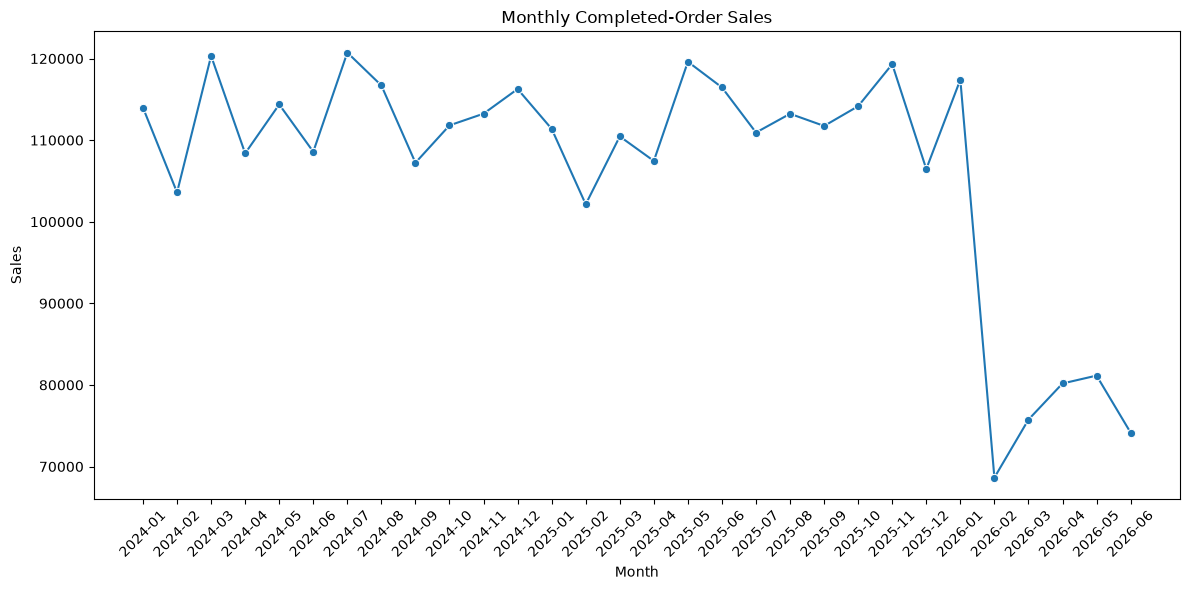

In [18]:
# Select valid completed transactions with usable order dates.
sales_data = analysis_df[
    analysis_df["CompletedSales"].notna()
    & analysis_df["OrderDate"].notna()
].copy()

# Aggregate sales and transaction counts by month.
sales_data["Month"] = (
    sales_data["OrderDate"].dt.to_period("M").astype(str)
)

monthly_sales = sales_data.groupby("Month").agg(
    TotalSales=("CompletedSales", "sum"),
    OrderCount=("OrderID", "nunique")
).reset_index()

print(monthly_sales)

# Plot the monthly sales trend.
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="TotalSales",
    marker="o"
)

plt.title("Monthly Completed-Order Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    CHART_DIR / "monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

      Category  CompletedSales
0  Electronics      1618686.50
1  Accessories       514636.55
2  Home Office       415210.00
3    Wearables       402237.75
4       Gaming       183668.00
5   Stationery        61411.00


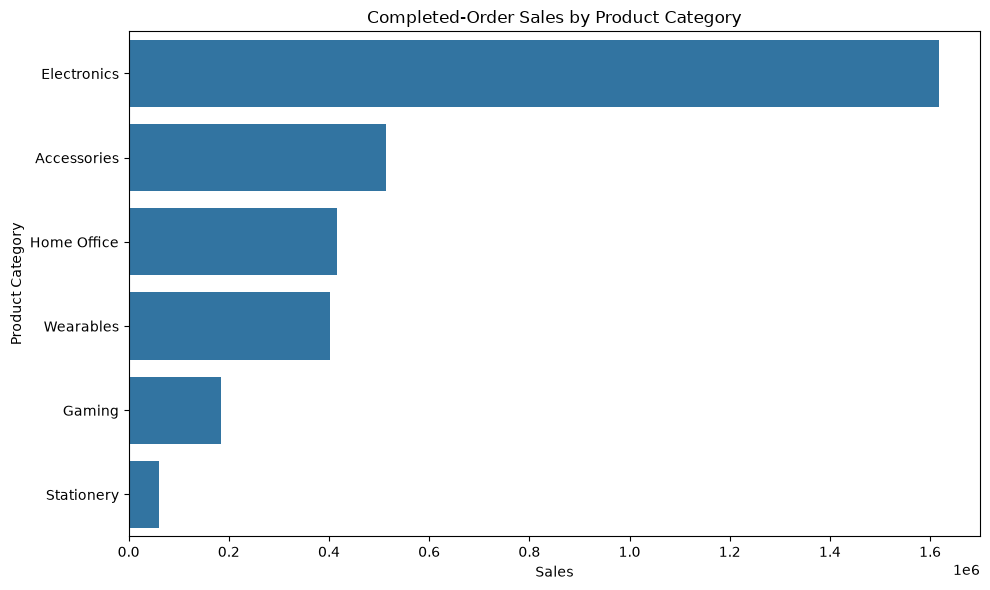

In [19]:
# Calculate completed-order sales by category.
category_sales = (
    sales_data.groupby("Category")["CompletedSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x="CompletedSales",
    y="Category"
)

plt.title("Completed-Order Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Product Category")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

           ProductName  CompletedSales
0           Headphones       313110.00
1         Office Chair       306378.00
2               Tablet       264394.00
3          Smart Watch       241140.00
4           Microphone       215781.00
5  Mechanical Keyboard       207842.60
6    Bluetooth Speaker       197263.80
7    Gaming Controller       183668.00
8           Power Bank       166911.50
9         Fitness Band       161097.75


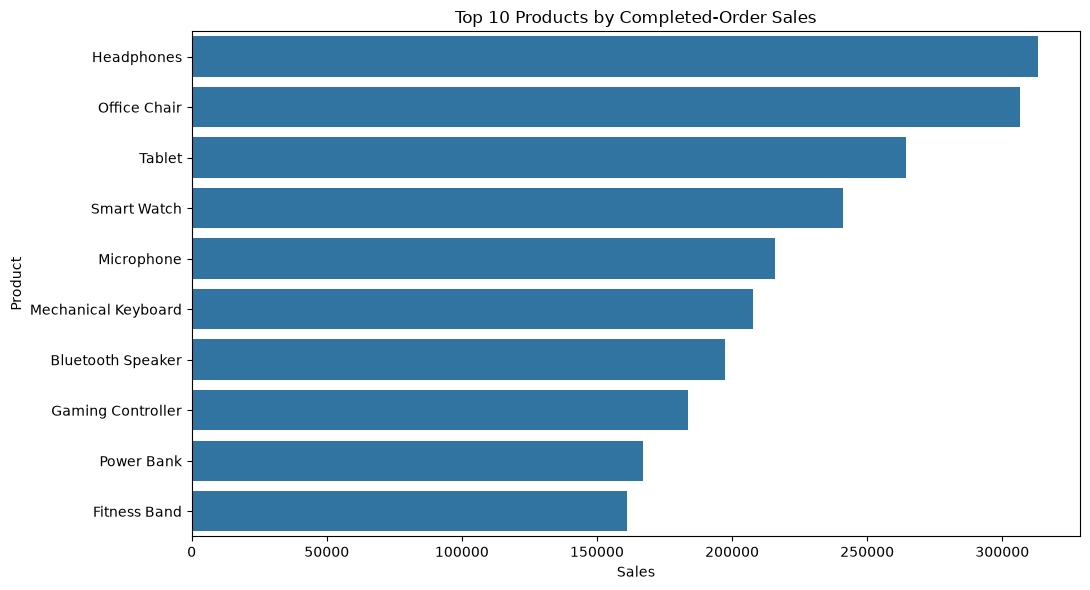

In [20]:
# Rank products by completed-order sales.
product_sales = (
    sales_data.groupby("ProductName")["CompletedSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products = product_sales.head(10)

print(top_products)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_products,
    x="CompletedSales",
    y="ProductName"
)

plt.title("Top 10 Products by Completed-Order Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "top_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

  CustomerSegment  TotalSales  AverageSale  OrderCount  UniqueCustomers
0             New  1108076.65    70.060486       15816             3424
1         Regular  1775094.75    70.222911       25278             5510
2             VIP   310770.00    68.466623        4539              966


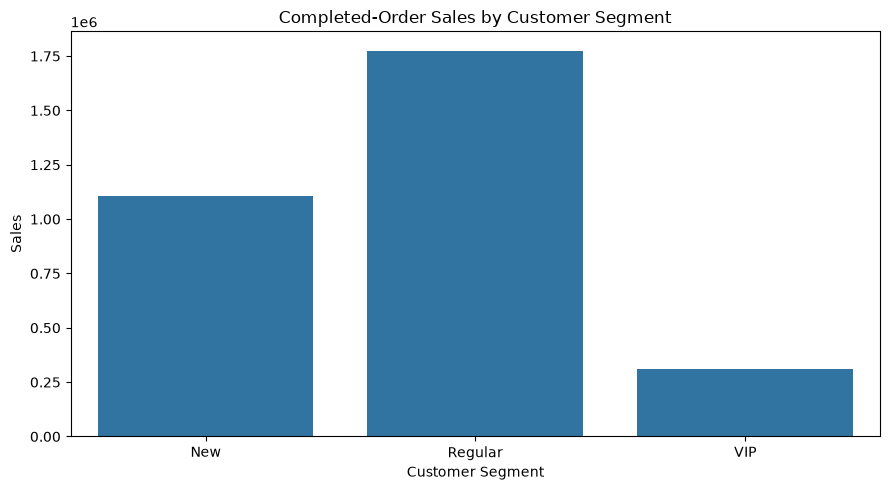

In [21]:
# Compare sales and transaction counts across customer segments.
segment_sales = sales_data.groupby("CustomerSegment").agg(
    TotalSales=("CompletedSales", "sum"),
    AverageSale=("CompletedSales", "mean"),
    OrderCount=("OrderID", "nunique"),
    UniqueCustomers=("CustomerID", "nunique")
).reset_index()

print(segment_sales)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_sales,
    x="CustomerSegment",
    y="TotalSales"
)

plt.title("Completed-Order Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "segment_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

      City  CompletedSales
0   Tehran       876414.35
1  Mashhad       402877.85
2    Karaj       319083.80
3  Isfahan       308149.70
4   Shiraz       288085.50
5   Tabriz       268162.95
6    Ahvaz       191669.55
7    Rasht       184907.75
8   Kerman       161619.00
9      Qom       149340.70


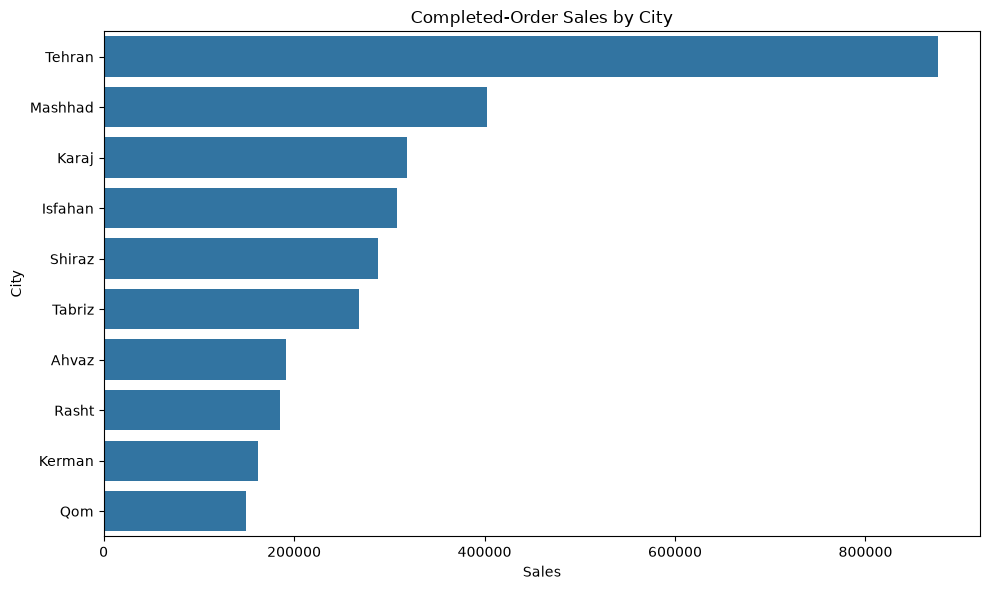

In [22]:
# Rank cities by completed-order sales.
city_sales = (
    sales_data.groupby("City")["CompletedSales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(city_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_sales,
    x="CompletedSales",
    y="City"
)

plt.title("Completed-Order Sales by City")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "city_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

      Status  Count
0  Completed  45996
1  Cancelled   2472
2   Returned   1532


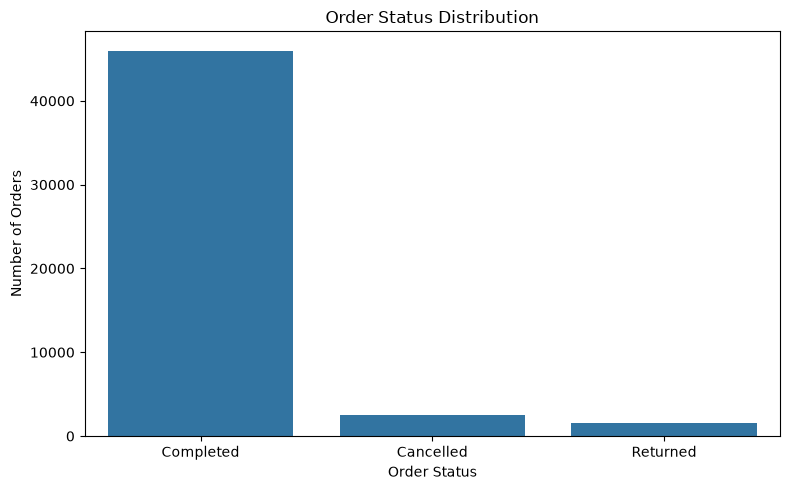

In [23]:
# Count each order status.
status_counts = (
    analysis_df["Status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Count")
)

print(status_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=status_counts,
    x="Status",
    y="Count"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "order_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

  PaymentMethod  Count
0       Gateway  23822
1    CardToCard  11946
2        Wallet   8782
3          Cash   5000


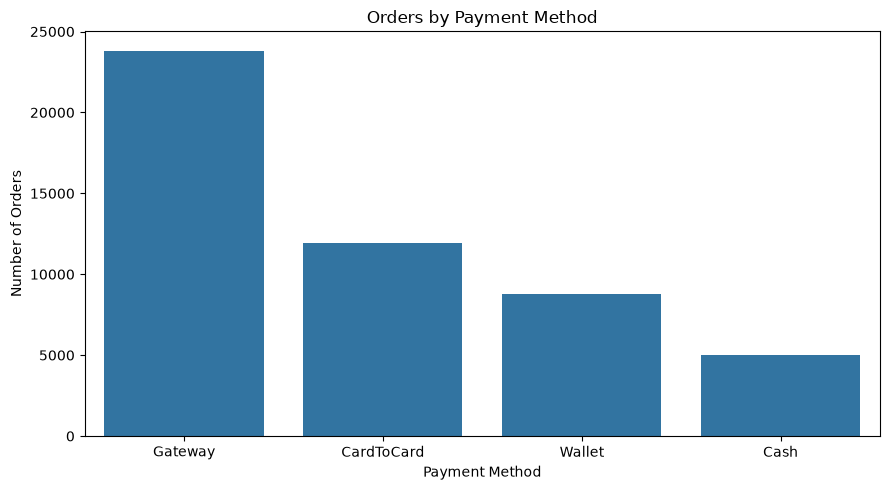

In [24]:
# Count orders by payment method.
payment_counts = (
    analysis_df["PaymentMethod"]
    .value_counts()
    .rename_axis("PaymentMethod")
    .reset_index(name="Count")
)

print(payment_counts)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_counts,
    x="PaymentMethod",
    y="Count"
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "payment_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Use records where both payment method and payment status are available.
payment_test_data = analysis_df.dropna(
    subset=["PaymentMethod", "PaymentStatus"]
)

# Create a contingency table.
payment_table = pd.crosstab(
    payment_test_data["PaymentMethod"],
    payment_test_data["PaymentStatus"]
)

print(payment_table)

# Perform the chi-square test of independence.
chi2, p_value, dof, expected = stats.chi2_contingency(
    payment_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

# Check the expected cell frequencies.
print(
    "Minimum expected frequency:",
    expected.min()
)

PaymentStatus  Failed   Paid  Refunded
PaymentMethod                         
CardToCard        465  11135       346
Cash              182   4684       134
Gateway           920  22169       733
Wallet            339   8162       281
Chi-square statistic: 4.571898609528647
Degrees of freedom: 6
P-value: 0.5997682243877789
Minimum expected frequency: 150.75681130171543


In [26]:
# Keep valid completed-order sales.
customer_sales_data = sales_data.dropna(
    subset=["CustomerID", "CustomerSegment", "CompletedSales"]
)

# Calculate total completed-order sales per customer.
customer_totals = customer_sales_data.groupby(
    ["CustomerID", "CustomerSegment"]
)["CompletedSales"].sum().reset_index(
    name="CustomerTotalSales"
)

# Prepare one independent observation per customer.
segment_groups = [
    group["CustomerTotalSales"].to_numpy()
    for _, group in customer_totals.groupby("CustomerSegment")
]

# Perform the Kruskal-Wallis test.
h_statistic, p_value = stats.kruskal(*segment_groups)

print("Kruskal-Wallis statistic:", h_statistic)
print("P-value:", p_value)

# Describe the observed customer-level sales distributions.
print(
    customer_totals.groupby("CustomerSegment")[
        "CustomerTotalSales"
    ].agg(["count", "median", "mean", "std"])
)

Kruskal-Wallis statistic: 2.4035276429330277
P-value: 0.30066342733786366
                 count   median        mean         std
CustomerSegment                                        
New               3424  267.350  323.620517  250.543624
Regular           5510  260.875  322.158757  254.049628
VIP                966  273.775  321.708075  223.413438


In [27]:
# Calculate the percentage represented by each order status.
status_summary = analysis_df["Status"].value_counts(
    dropna=False
).to_frame("OrderCount")

status_summary["Percentage"] = (
    status_summary["OrderCount"]
    / len(analysis_df)
    * 100
).round(2)

print(status_summary)

           OrderCount  Percentage
Status                           
Completed       45996       91.99
Cancelled        2472        4.94
Returned         1532        3.06
